<a href="https://colab.research.google.com/github/WILLIAMS-star-hash/ML-For-Beginners/blob/main/Financial_Data_First_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# i have Chosen IVV

In [3]:
import yfinance as yf
import pandas as pd

ticker = "IVV"
data = yf.download(ticker, start="2010-01-01", end="2020-01-01")

# Fix MultiIndex
data.columns = data.columns.droplevel(1)

# Create target
data['Open_shift'] = data['Open'].shift(1)
data['Target'] = (data['Open'] > data['Open_shift']).astype(int)

# Features
data['Return'] = data['Close'].pct_change()
data['SMA_5'] = data['Close'].rolling(5).mean()
data['SMA_10'] = data['Close'].rolling(10).mean()
data['Volatility'] = data['Close'].rolling(5).std()
data['Volume_Change'] = data['Volume'].pct_change()

data = data.dropna()

/tmp/ipykernel_9619/641051674.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2010-01-01", end="2020-01-01")
[*********************100%***********************]  1 of 1 completed


In [4]:
print(data.head())
print(data.dtypes)

Price           Close       High        Low       Open   Volume  Open_shift  \
Date                                                                          
2010-01-15  85.146072  86.042345  84.817437  85.885497  5227700   85.833219   
2010-01-19  86.199211  86.258958  85.108739  85.146086  3430200   85.885497   
2010-01-20  85.347710  85.639004  84.653097  85.616592  7105900   85.146086   
2010-01-21  83.674706  85.609168  83.577611  85.362691  9015900   85.616592   
2010-01-22  81.867218  83.637362  81.755183  83.338603  7485100   85.362691   

Price       Target    Return      SMA_5     SMA_10  Volatility  Volume_Change  
Date                                                                           
2010-01-15       1 -0.011275  85.659946  85.494886    0.457825       1.004486  
2010-01-19       0  0.012369  85.703261  85.626337    0.503913      -0.343841  
2010-01-20       1 -0.009878  85.734625  85.647995    0.467623       1.071570  
2010-01-21       0 -0.019602  85.296948  85.49

In [5]:
# then running correlation
corr = data.corr(numeric_only=True)['Target'].sort_values(ascending=False)
print(corr)

Price
Target           1.000000
Return           0.243065
Low              0.035808
Open             0.033691
Close            0.033556
High             0.031776
SMA_5            0.021968
SMA_10           0.019210
Open_shift       0.016525
Volatility      -0.020614
Volume_Change   -0.023600
Volume          -0.108752
Name: Target, dtype: float64


In [6]:
# features to use
features = ['Return', 'Volume', 'Low', 'SMA_5']

In [7]:
# Now the big part: cross-validation

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np

# Features and target
features = ['Return', 'Volume', 'Low', 'SMA_5']
X = data[features]
y = data['Target']

# K-Fold setup
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Model with scaling + increased iterations
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

accuracies = []

# Cross-validation loop
for train_index, test_index in kf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)

# Results
print("Fold Accuracies:", accuracies)
print("Mean Accuracy:", np.mean(accuracies))

Fold Accuracies: [0.6812749003984063, 0.6175298804780877, 0.6733067729083665, 0.6693227091633466, 0.6812749003984063, 0.6693227091633466, 0.601593625498008, 0.64, 0.64, 0.66]
Mean Accuracy: 0.6533625498007967


In [10]:
import pandas as pd

results_table = pd.DataFrame({
    'Fold': list(range(1, 11)),
    'Accuracy': accuracies
})

# Add mean row
mean_row = pd.DataFrame({'Fold': ['Mean'], 'Accuracy': [np.mean(accuracies)]})
results_table = pd.concat([results_table, mean_row], ignore_index=True)

print(results_table)

    Fold  Accuracy
0      1  0.681275
1      2  0.617530
2      3  0.673307
3      4  0.669323
4      5  0.681275
5      6  0.669323
6      7  0.601594
7      8  0.640000
8      9  0.640000
9     10  0.660000
10  Mean  0.653363


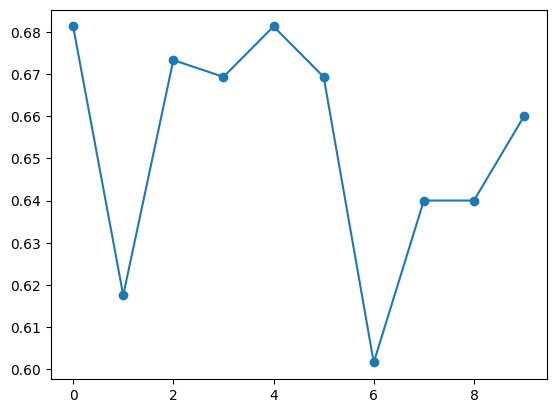

In [13]:
# CREATING Accuracy graph
import matplotlib.pyplot as plt

plt.plot(accuracies, marker='o')

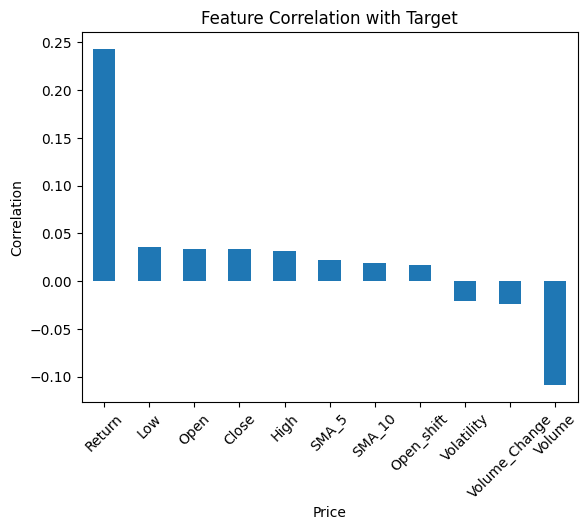

In [14]:
# feature importancecorrelation
corr.drop('Target').plot(kind='bar')
plt.title("Feature Correlation with Target")
plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.show()